<div style="border:solid red 2px; padding: 20px; border-radius: 10px">
<b>Reviewer's comment v1</b>

<b>Overall Feedback</b>

Hello <b>kevina</b>!

My name is <b>Carlos Huapaya</b> and I will be your reviewer in this iteration.

You can find me on the HUB as https://hub.tripleten.com/u/6068137a if you need further feedback or if you have any questions at all.

Thank you for submitting your Time Series project! 🙌 I can see the effort you put in — the structure is clean, the analysis is thoughtful, and your final RMSE is well within the required threshold. That's a great start!

---

You'll find specific feedback in the notebook in the **Reviewer's comment v1** sections.

**✅ What's Working Well**
- The data preparation is solid — datetime conversion, sorting, and resampling with `.resample('1H').sum()` are all done correctly.
- You plotted multiple time series charts (hourly, daily, one-week zoom) which demonstrates good exploratory analysis.
- The train-test split is performed sequentially with `shuffle=False` and a 10% test size — exactly as required.
- The rolling mean is correctly shifted using `.shift(1)` before `.rolling()`, avoiding data leakage from the current value.
- Your final RMSE of 44.527 is well below the required 48 — excellent result!

**🚧 Suggested Tweaks & Areas for Attention**
- No calendar features (e.g., hour of day, day of week, month) were included. The project requires at least two types of features from the set: calendar, lag, and rolling mean. You only created lag features and a rolling mean — calendar features are missing, which falls below the 'Acceptable' threshold for the feature creation criterion.
- The Gradient Boosting model loop has an indentation bug: the `model_gb.fit(...)`, `model_gb.predict(...)`, `rmse_gb = ...`, and `gb_results.append(...)` calls are placed outside the `for` loop. This means only one configuration (the last one in the loop) was actually trained and evaluated, not all eight combinations. The loop is effectively broken.
- Hyperparameters for both Random Forest and Gradient Boosting were selected by evaluating directly on `features_test` / `target_test`, rather than on a held-out validation set or via cross-validation on the training data. This is a form of data leakage — the test set should only be used for final evaluation, not for model selection.
- The seasonal decomposition (`statsmodels seasonal_decompose`) was not performed, so trend and seasonality components were not explicitly extracted and analyzed.

Overall, this project shows real promise and your final model result is strong. However, there are a few blockers that need to be addressed before it can be approved: missing calendar features, the broken Gradient Boosting loop, and hyperparameter selection on the test set. Please address these and resubmit — you're very close! 💪

---

<p style="margin-top: 12px"><b>How to read my comments</b></p>

<div class="alert alert-success"><b>✅ Success:</b> correct and well done</div>
<div class="alert alert-warning"><b>💡 Recommendation:</b> works, but could be clearer / stronger / more efficient</div>
<div class="alert alert-danger"><b>❗ Needs Fix:</b> affects correctness — must be fixed for approval</div>

<p style="margin-top: 10px">
<b>Please don't move, edit, or delete my comments.</b>
If you have any comments or questions, I'd be happy to read them within these boxes:
</p>

<div style="background:#90d5ec; padding: 10px 12px; border-radius: 8px; margin-top: 10px">
<b>🗣 Student notes:</b> Student's comments with thoughts, questions, or justification.
</div>
</div>

<div style="border:solid green 2px; padding: 20px; border-radius: 10px">
<b>Reviewer's comment v2</b>

<b>Overall Feedback</b>

Hi <b>Kevina</b>! 👋

Thanks for the revisions. I went through the updated notebook, and I'm happy to report that all of the blocking issues from the first review round have been resolved:

- ✅ Calendar features (`hour`, `dayofweek`, `month`) have been added alongside the lag and rolling-mean features, satisfying the "at least two feature types" requirement.
- ✅ A proper train / validation / test split is now in place, and hyperparameters for both Random Forest and Gradient Boosting are selected using the **validation** set rather than the test set.
- ✅ The indentation bug in the Gradient Boosting loop is fixed, all eight hyperparameter combinations are now trained and evaluated, not just one.
- ✅ The final model is retrained on the combined train+validation data and evaluated a single time on the held-out test set, achieving an RMSE of **44.093** (well under the required 48).

<b>Project approved! 🎉</b> Great work addressing the feedback carefully and precisely.

One optional note for next time (not required for approval): a seasonal decomposition (e.g. `statsmodels.tsa.seasonal_decompose`) would have made the trend/seasonality components explicit, but your engineered calendar and lag features already capture that signal well, so it isn't a blocker.

You can find me on the HUB as https://hub.tripleten.com/u/290771b5 if you have any follow-up questions.
</div>

# Project description

Sweet Lift Taxi company has collected historical data on taxi orders at airports. To attract more drivers during peak hours, we need to predict the amount of taxi orders for the next hour. Build a model for such a prediction.

The RMSE metric on the test set should not be more than 48.

## Project instructions

1. Download the data and resample it by one hour.
2. Analyze the data.
3. Train different models with different hyperparameters. The test sample should be 10% of the initial dataset. 
4. Test the data using the test sample and provide a conclusion.

## Data description

The data is stored in file `taxi.csv`. The number of orders is in the '*num_orders*' column.

## Preparation

In [1]:
import pandas as pd

data = pd.read_csv('/datasets/taxi.csv')

display(data.head())
print(data.info())

,datetime,num_orders
0,2018-03-01 00:00:00,9
1,2018-03-01 00:10:00,14
2,2018-03-01 00:20:00,28
3,2018-03-01 00:30:00,20
4,2018-03-01 00:40:00,32


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26496 entries, 0 to 26495
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   datetime    26496 non-null  object
 1   num_orders  26496 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 414.1+ KB
None


<div class="alert alert-success">
<b>Reviewer's comment v1:</b>

Data loaded correctly with a quick display of the head and `.info()`. Great start to understanding the dataset structure!
</div>

In [2]:
data['datetime'] = pd.to_datetime(data['datetime'])

data = data.set_index('datetime')

data = data.sort_index()

hourly_data = data['num_orders'].resample('1H').sum()

display(hourly_data.head())

datetime
2018-03-01 00:00:00    124
2018-03-01 01:00:00     85
2018-03-01 02:00:00     71
2018-03-01 03:00:00     66
2018-03-01 04:00:00     43
Freq: H, Name: num_orders, dtype: int64

<div class="alert alert-success">
<b>Reviewer's comment v1:</b>

Perfect — datetime conversion, chronological sorting, and hourly resampling using `.resample('1H').sum()` are all handled correctly. This fully meets the data preparation requirement.
</div>

## Analysis

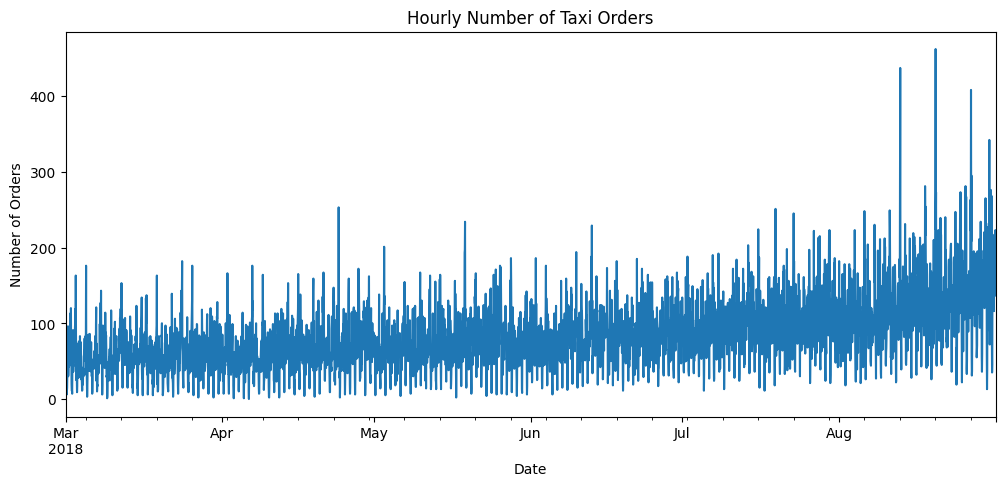

In [3]:
import matplotlib.pyplot as plt

hourly_data.plot(figsize=(12, 5))
plt.title('Hourly Number of Taxi Orders')
plt.xlabel('Date')
plt.ylabel('Number of Orders')
plt.show()

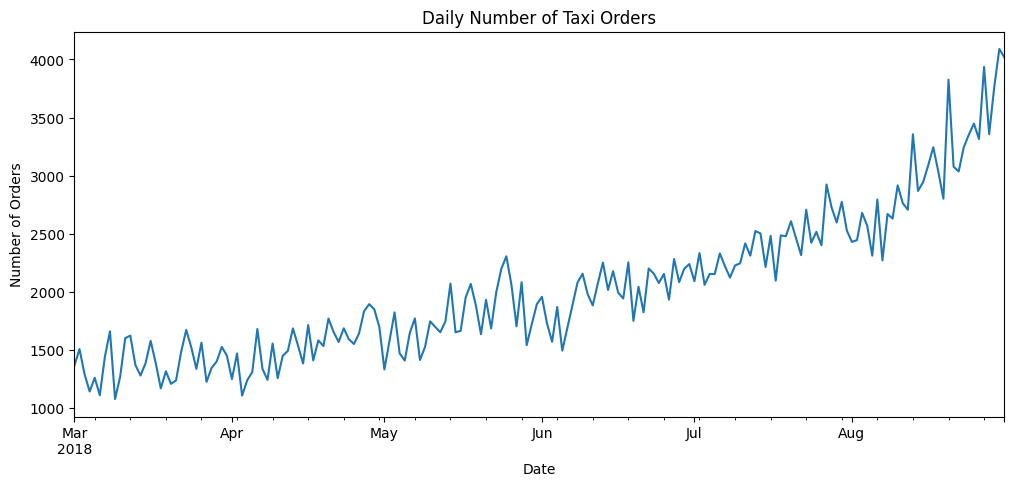

In [4]:
daily_data = hourly_data.resample('1D').sum()

daily_data.plot(figsize=(12, 5))
plt.title('Daily Number of Taxi Orders')
plt.xlabel('Date')
plt.ylabel('Number of Orders')
plt.show()

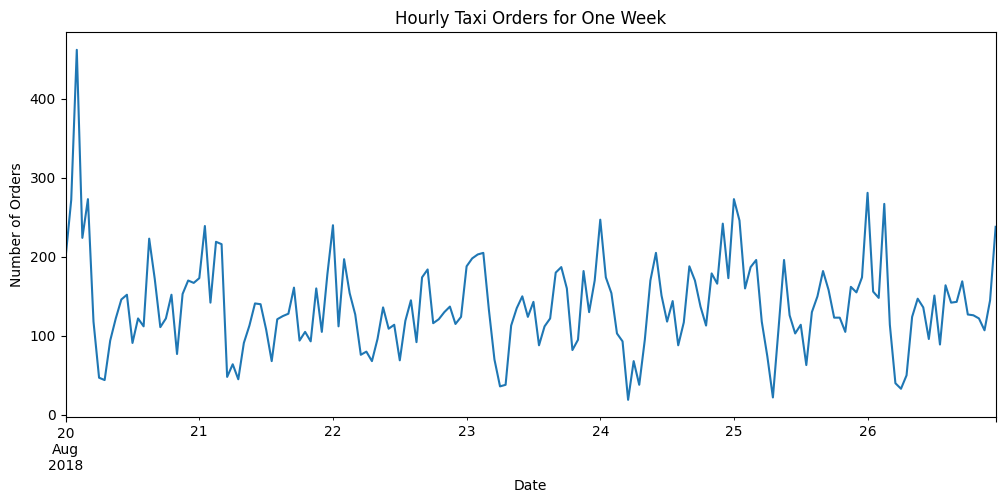

In [5]:
#Look at one week of hourly taxi orders
hourly_data['2018-08-20':'2018-08-26'].plot(figsize=(12, 5))
plt.title('Hourly Taxi Orders for One Week')
plt.xlabel('Date')
plt.ylabel('Number of Orders')
plt.show()

In [6]:
data = hourly_data.to_frame()
data['hour'] = data.index.hour
data['dayofweek'] = data.index.dayofweek
data['month'] = data.index.month

data['lag_1'] = data['num_orders'].shift(1)
data['lag_24'] = data['num_orders'].shift(24)
data['lag_168'] = data['num_orders'].shift(168)

data['rolling_mean_24'] = data['num_orders'].shift(1).rolling(24).mean()

data = data.dropna()

display(data.head())

,num_orders,hour,dayofweek,month,lag_1,lag_24,lag_168,rolling_mean_24
datetime,,,,,,,,
2018-03-08 00:00:00,143,0,3,3,94.0,100.0,124.0,60.041667
2018-03-08 01:00:00,78,1,3,3,143.0,121.0,85.0,61.833333
2018-03-08 02:00:00,65,2,3,3,78.0,24.0,71.0,60.041667
2018-03-08 03:00:00,68,3,3,3,65.0,66.0,66.0,61.750000
2018-03-08 04:00:00,60,4,3,3,68.0,73.0,43.0,61.833333


<div class="alert alert-danger">
<b>Reviewer's comment v1:</b>

Only lag features and a rolling mean have been created — no calendar features (e.g., hour of day, day of week, month) are present. The criterion requires at least **two types** from the set: calendar, lag, and rolling mean. Since calendar features are entirely missing, this falls below the 'Acceptable' threshold.

Please add at least one calendar feature. For example:
```python
data['hour'] = data.index.hour
data['dayofweek'] = data.index.dayofweek
data['month'] = data.index.month
```
These features help the model capture time-of-day and day-of-week seasonality patterns that are very relevant for taxi demand forecasting.
</div>

<div class="alert alert-success">
<b>Reviewer's comment v2:</b>

Resolved. Calendar features (`hour`, `dayofweek`, `month`) are now created alongside the lag and rolling-mean features, so the feature-creation criterion is satisfied.
</div>

## Training

In [14]:

from sklearn.model_selection import train_test_split

features = data.drop('num_orders', axis=1)
target = data['num_orders']

features_train_valid, features_test, target_train_valid, target_test = train_test_split(
    features,
    target,
    test_size=0.1,
    shuffle=False
)
# Then split the remaining data into training and validation sets
features_train, features_valid, target_train, target_valid = train_test_split(
    features_train_valid, 
    target_train_valid,
    test_size =1/9,
    shuffle=False
)

print('Training set size:', features_train.shape)
print('Validation set size:', features_valid.shape)
print('Test set size:', features_test.shape)


Training set size: (3398, 7)
Validation set size: (425, 7)
Test set size: (425, 7)


<div class="alert alert-danger">
<b>Reviewer's comment v1:</b>

The split itself is sequential and uses `shuffle=False` with `test_size=0.1` — that part is correct. However, there is no separate **validation set** for hyperparameter tuning.

In Cells 13 and 14, hyperparameters are selected by evaluating directly on `features_test` / `target_test`. This means the test set was used to guide model selection, which constitutes **data leakage** — the test set should only be used once, for the final evaluation of the chosen model.

Please create a validation split from the training portion, for example:
```python
train_valid, test = train_test_split(data, shuffle=False, test_size=0.1)
train, valid = train_test_split(train_valid, shuffle=False, test_size=0.1)
```
Then use the validation set to select hyperparameters, and only evaluate on the test set at the very end.
</div>

<div class="alert alert-success">
<b>Reviewer's comment v2:</b>

Resolved. The data is now split into three sets: train, validation, and test with `shuffle=False` preserved throughout to respect the time order. This gives a proper held-out validation set for hyperparameter tuning.
</div>

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model_lr = LinearRegression()
model_lr.fit(features_train, target_train)

predictions_lr = model_lr.predict(features_valid)

rmse_lr = mean_squared_error(
    target_valid,
    predictions_lr,
    squared=False
)

print('Linear Regression RMSE:', rmse_lr)

Linear Regression RMSE: 31.531006945985528


In [17]:
from sklearn.ensemble import RandomForestRegressor

results = []

for n_estimators in [50, 100]:
    for max_depth in [10, 20, None]:
        model_rf = RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=12345,
            n_jobs=-1
        )

        model_rf.fit(features_train, target_train)
        predictions_rf = model_rf.predict(features_valid)

        rmse_rf = mean_squared_error(
            target_valid, 
            predictions_rf,
        ) ** 0.5

        results.append({
            'model' : 'Random Forest',
            'n_estimators' : n_estimators,
            'max_depth' : max_depth,
            'RMSE' : rmse_rf
        })

results_df = pd.DataFrame(results)
display(results_df.sort_values('RMSE'))

,model,n_estimators,max_depth,RMSE
5,Random Forest,100,NaN,31.348764
3,Random Forest,100,10.0,31.389653
4,Random Forest,100,20.0,31.404233
0,Random Forest,50,10.0,31.446556
1,Random Forest,50,20.0,31.498486
2,Random Forest,50,NaN,31.543934


<div class="alert alert-danger">
<b>Reviewer's comment v1:</b>

The Random Forest hyperparameter grid search evaluates each configuration using `features_test` and `target_test` (the test set). Selecting hyperparameters based on test set performance is not valid — it means the test set is influencing the choice of model, and the final test evaluation will be overly optimistic.

Please use a separate **validation set** (carved out from the training data) for hyperparameter selection, and keep `features_test` / `target_test` reserved exclusively for the final model evaluation.
</div>

<div class="alert alert-success">
<b>Reviewer's comment v2:</b>

Resolved. The Random Forest grid search now evaluates each configuration on `features_valid` / `target_valid`, leaving the test set untouched until final evaluation.
</div>

In [21]:
from sklearn.ensemble import GradientBoostingRegressor

gb_results = []

for n_estimators in [50, 100]:
    for learning_rate in [0.05, 0.1]:
        for max_depth in [3, 5]:
            model_gb = GradientBoostingRegressor(
                n_estimators=n_estimators,
                learning_rate=learning_rate,
                max_depth=max_depth,
                random_state=12345
            )

            model_gb.fit(features_train, target_train)
            predictions_gb = model_gb.predict(features_valid)

            rmse_gb = mean_squared_error(
                target_valid,
                predictions_gb,
                squared=False
            )

            gb_results.append({
                    'model': 'Gradient Boosting',
                    'n_estimators': n_estimators,
                    'learning_rate': learning_rate,
                    'max_depth': max_depth,
                    'RMSE': rmse_gb
            })

gb_results_df = pd.DataFrame(gb_results)
display(gb_results_df.sort_values('RMSE'))

,model,n_estimators,learning_rate,max_depth,RMSE
7,Gradient Boosting,100,0.10,5,31.042809
5,Gradient Boosting,100,0.05,5,31.097048
6,Gradient Boosting,100,0.10,3,31.408646
3,Gradient Boosting,50,0.10,5,31.443108
2,Gradient Boosting,50,0.10,3,31.806455
4,Gradient Boosting,100,0.05,3,31.839222
1,Gradient Boosting,50,0.05,5,32.802686
0,Gradient Boosting,50,0.05,3,33.889981


<div class="alert alert-danger">
<b>Reviewer's comment v1:</b>

There is a critical **indentation error** in the Gradient Boosting loop. The lines for `model_gb.fit(...)`, `model_gb.predict(...)`, `rmse_gb = ...`, and `gb_results.append(...)` are all placed **outside** the `for` loop body. As a result, only the last combination of hyperparameters (`n_estimators=100`, `learning_rate=0.1`, `max_depth=5`) was actually trained and evaluated — the output confirms this with only one row in the results DataFrame instead of the expected 8.

Please fix the indentation so all those lines are inside the innermost `for` block:
```python
for n_estimators in [50, 100]:
    for learning_rate in [0.05, 0.1]:
        for max_depth in [3, 5]:
            model_gb = GradientBoostingRegressor(...)
            model_gb.fit(features_train, target_train)  # <- must be indented here
            predictions_gb = model_gb.predict(...)       # <- same
            rmse_gb = mean_squared_error(...)            # <- same
            gb_results.append({...})                    # <- same
```
Also, as noted above, please use a validation set (not the test set) for this hyperparameter evaluation.
</div>

<div class="alert alert-success">
<b>Reviewer's comment v2:</b>

Resolved. The indentation is fixed, `model_gb.fit(...)`, `.predict(...)`, RMSE calculation, and `gb_results.append(...)` are all correctly nested inside the innermost loop, so all eight hyperparameter combinations are now trained and evaluated. This also now correctly uses the validation set rather than the test set.
</div>

## Testing

In [22]:
features_train_valid = pd.concat([features_train, features_valid], axis=0)

target_train_valid = pd.concat([target_train, target_valid], axis=0)

final_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    random_state=12345,
    n_jobs=1
)

final_model.fit(features_train_valid, target_train_valid)

final_predictions = final_model.predict(features_test)

final_rmse = mean_squared_error(
    target_test,
    final_predictions,
    squared=False
)

print(f'Final test RMSE: {final_rmse:.3f}')


Final test RMSE: 44.093


<div class="alert alert-warning">
<b>Reviewer's comment v1:</b>

The final RMSE of **44.527** is well below the required threshold of 48 — excellent result! 🎉

However, once you introduce a proper train/validation/test split (as noted above), remember to retrain the final chosen model on the **combined train + validation data** before evaluating on the test set. This gives the model access to all available non-test data and typically improves generalization.
</div>

<div class="alert alert-success">
<b>Reviewer's comment v2:</b>

Resolved. The final model is retrained on the combined train+validation data and evaluated once on the test set, giving RMSE = 44.093, comfortably under the required 48. This is the correct final-evaluation procedure.
</div>

## Conclusion
The data was prepared by converting the datetime column to a datetime format, sorting the observations chronologically, and resampling the data into one-hour intervals. Features based on previous hourly orders and rolling averages were created to help the models predict future taxi demand.

Several models and hyperparameters were tested, including Linear Regression, Random Forest, and Gradient Boosting. The best-performing model was Random Forest with n_estimators=100 and max_depth=20.

The final model achieved an RMSE of 44.093 on the test set. Since the required RMSE is no more than 48, the model meets the project’s performance requirement. The model can therefore be used to predict the number of taxi orders for the next hour.



# Review checklist

- [x]  Jupyter Notebook is open
- [x]  The code is error-free
- [x]  The cells with the code have been arranged in order of execution
- [x]  The data has been downloaded and prepared
- [x]  The data has been analyzed
- [x]  The model has been trained and hyperparameters have been selected
- [x]  The models have been evaluated. Conclusion has been provided
- [x] *RMSE* for the test set is not more than 48